In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df = pd.read_csv('placement.csv')

In [85]:
df.shape

(1000, 3)

In [86]:
df.sample(5)

,cgpa,placement_exam_marks,placed
745,6.82,13.0,1
96,7.09,28.0,1
228,7.61,15.0,0
440,8.56,22.0,0
689,8.02,67.0,0


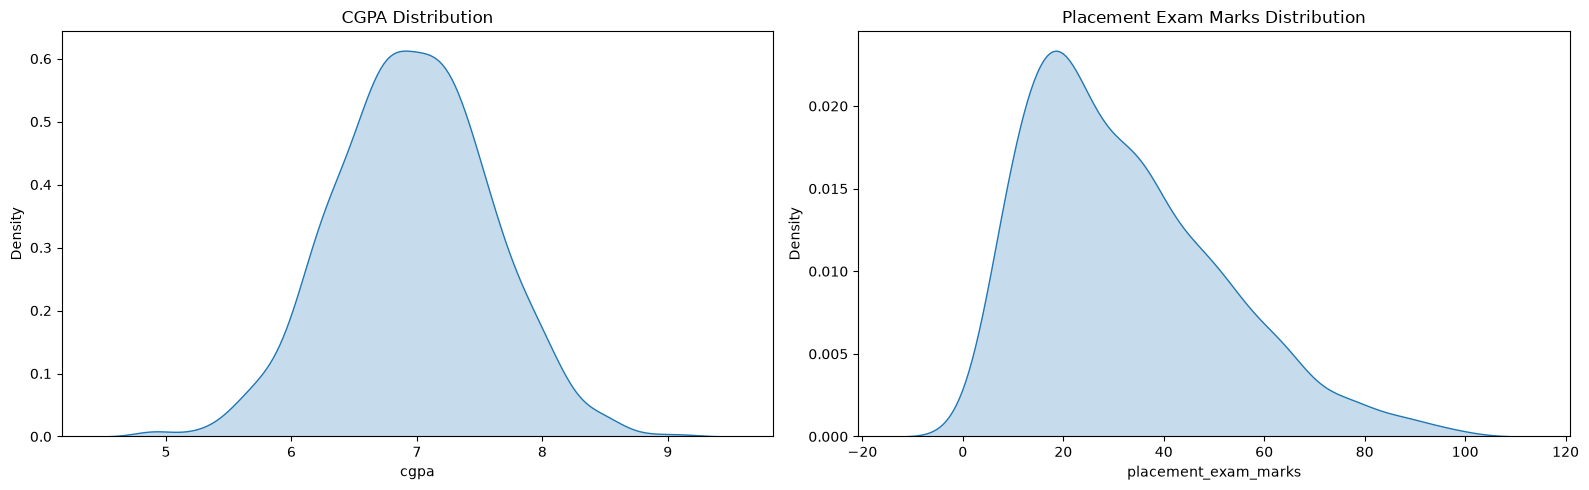

In [ ]:
# Create a new figure of size 16x5 inches
plt.figure(figsize=(16, 5))

# ---------------- First Plot ----------------
# Create the first subplot (1 row, 2 columns(Box1,Box2), position 1)
# +----------------+----------------+
# |      Box 1     |      Box 2     |
# |    (Current)   |                |
# +----------------+----------------+
plt.subplot(1, 2, 1)

# Plot the KDE (Kernel Density Estimation) distribution of CGPA
sns.kdeplot(df['cgpa'], fill=True)

# Add title to the first plot
plt.title("CGPA Distribution")

# ---------------- Second Plot ----------------
# Create the second subplot (1 row, 2 columns(Box1,Box2), position 2)
# +----------------+----------------+
# |      Box 1     |      Box 2     |
# |                |   (Current)    |
# +----------------+----------------+
plt.subplot(1, 2, 2)

# Plot the KDE distribution of Placement Exam Marks
sns.kdeplot(df['placement_exam_marks'], fill=True)

# Add title to the second plot
plt.title("Placement Exam Marks Distribution")

# Automatically adjust spacing between subplots
plt.tight_layout()

# Display the figure
plt.show()

In [106]:
# Check the skewness of the feature to understand its distribution
# Skewness Interpretation:
# ≈ 0      -> Symmetric (Normally Distributed)
# -0.5 to 0.5  -> Approximately Symmetric
# -1 to -0.5   -> Moderately Left-Skewed (Negative Skew)
# 0.5 to 1     -> Moderately Right-Skewed (Positive Skew)
# < -1         -> Highly Left-Skewed
# > 1          -> Highly Right-Skewed

df['cgpa'].skew()

np.float64(-0.003704380991302917)

In [89]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


In [90]:
# Finding the boundary values
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [91]:
# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Trimming

In [92]:
# Trimming

new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [ ]:
# Approach 2

# Calculating the Zscore
# Xi' = Xi - M / S.D
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [94]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [95]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [96]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [97]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [98]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [99]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## Capping

In [100]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [101]:
lower_limit

np.float64(5.113546374602832)

In [ ]:
# Cap (clip) outliers using the lower and upper limits
# np.where(condition, value_if_true, value_if_false)

df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,      # If CGPA is above the upper limit
    upper_limit,                   # Replace it with the upper limit
    np.where(
        df['cgpa'] < lower_limit,  # Else, if CGPA is below the lower limit
        lower_limit,               # Replace it with the lower limit
        df['cgpa']                 # Otherwise, keep the original value
    )
)

In [103]:
df.shape

(1000, 4)

In [104]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64